# Weight EMA — Hands-On

Exponential Moving Average of model weights: keep a slow **shadow** copy
`v_t = β·v_{t-1} + (1-β)·θ_t`, evaluate with `v` instead of the raw weights `θ`.

This notebook shows, on CPU:
1. **Variance reduction** on a toy noisy-optimization problem (the core mechanism).
2. **Decay ↔ averaging window** `N ≈ 1/(1-β)` and the warmup schedule.
3. A **real MLP on digits** where EMA gives a smoother, better validation curve.
4. The **BatchNorm-buffer pitfall** (EMA-ing only parameters evaluates terribly).

Companion to [weight_ema.md](weight_ema.md).


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0); np.random.seed(0)


class ModelEMA:
    """Shadow EMA over the FULL state_dict (parameters + buffers), with warmup decay."""
    def __init__(self, model, decay=0.999, warmup=True):
        self.decay, self.warmup, self.t = decay, warmup, 0
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        self.t += 1
        d = min(self.decay, (1 + self.t) / (10 + self.t)) if self.warmup else self.decay
        for k, v in model.state_dict().items():
            s = self.shadow[k]
            if v.dtype.is_floating_point:
                s.mul_(d).add_(v.detach(), alpha=1 - d)   # params + float buffers (BN stats)
            else:
                s.copy_(v)                                # int buffers (num_batches_tracked)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

print("ModelEMA ready")


ModelEMA ready


## 1. The Core Mechanism: Variance Reduction

SGD with a finite learning rate does **not** stop at the minimum — it bounces around it with a
stationary variance set by the LR and gradient noise. We optimize a simple 2-D quadratic
`L(w) = ½‖w‖²` with **noisy gradients** and watch the raw iterate `θ` vs its EMA `v`.


In [2]:
# Noisy gradient descent on L(w) = 0.5 * ||w||^2  (optimum at origin)
def run_toy(lr=0.3, beta=0.95, steps=4000, noise=1.0, seed=0):
    rng = np.random.default_rng(seed)
    w = np.array([4.0, 4.0])          # start away from optimum
    v = w.copy()                       # EMA shadow
    W, V = [], []
    for t in range(1, steps + 1):
        grad = w + noise * rng.standard_normal(2)     # true grad (=w) + zero-mean noise
        w = w - lr * grad
        v = beta * v + (1 - beta) * w                 # EMA update (constant decay here)
        W.append(w.copy()); V.append(v.copy())
    return np.array(W), np.array(V)

W, V = run_toy()

# Use the second half (stationary regime) to measure spread around the optimum
half = len(W) // 2
raw_std = np.linalg.norm(W[half:], axis=1).std()
ema_std = np.linalg.norm(V[half:], axis=1).std()
raw_dist = np.linalg.norm(W[half:], axis=1).mean()
ema_dist = np.linalg.norm(V[half:], axis=1).mean()
beta = 0.95
print(f"mean distance to optimum  raw={raw_dist:.3f}  ema={ema_dist:.3f}")
print(f"std of distance           raw={raw_std:.3f}  ema={ema_std:.3f}  -> {raw_std/ema_std:.1f}x tighter")
print(f"theoretical std ratio sqrt((1+b)/(1-b)) = {np.sqrt((1+beta)/(1-beta)):.1f}x (white-noise ideal)")


mean distance to optimum  raw=0.552  ema=0.197
std of distance           raw=0.282  ema=0.105  -> 2.7x tighter
theoretical std ratio sqrt((1+b)/(1-b)) = 6.2x (white-noise ideal)


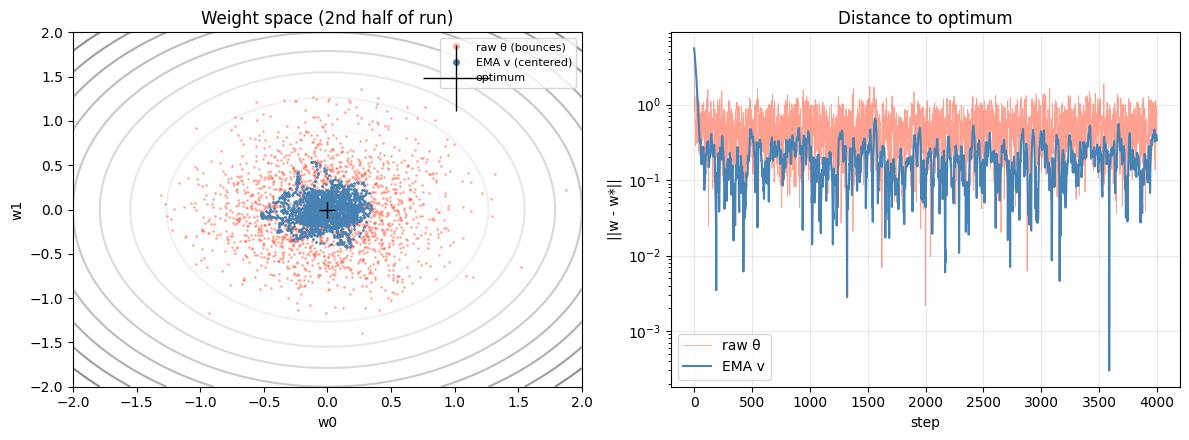

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) trajectories over the loss contour (zoom near optimum)
g = np.linspace(-2, 2, 80); gx, gy = np.meshgrid(g, g)
ax[0].contour(gx, gy, 0.5*(gx**2+gy**2), levels=12, cmap='Greys', alpha=0.5)
ax[0].plot(W[half:,0], W[half:,1], '.', ms=2, color='tomato', alpha=0.4, label='raw θ (bounces)')
ax[0].plot(V[half:,0], V[half:,1], '.', ms=2, color='steelblue', label='EMA v (centered)')
ax[0].plot(0, 0, 'k+', ms=12, label='optimum')
ax[0].set_xlim(-2,2); ax[0].set_ylim(-2,2); ax[0].set_title('Weight space (2nd half of run)')
ax[0].legend(markerscale=4, fontsize=8); ax[0].set_xlabel('w0'); ax[0].set_ylabel('w1')

# (b) distance-to-optimum over time
ax[1].plot(np.linalg.norm(W, axis=1), color='tomato', alpha=0.6, lw=0.6, label='raw θ')
ax[1].plot(np.linalg.norm(V, axis=1), color='steelblue', lw=1.5, label='EMA v')
ax[1].set_yscale('log'); ax[1].set_xlabel('step'); ax[1].set_ylabel('||w - w*||')
ax[1].set_title('Distance to optimum'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2. Decay ↔ Averaging Window

The geometric weights have a center of mass `N ≈ 1/(1-β)` — the effective number of recent steps
averaged. Pick β so `N` is a meaningful fraction of your total steps. The **warmup** schedule
`β_t = min(β, (1+t)/(10+t))` ramps β up so the shadow isn't stuck near init early on.


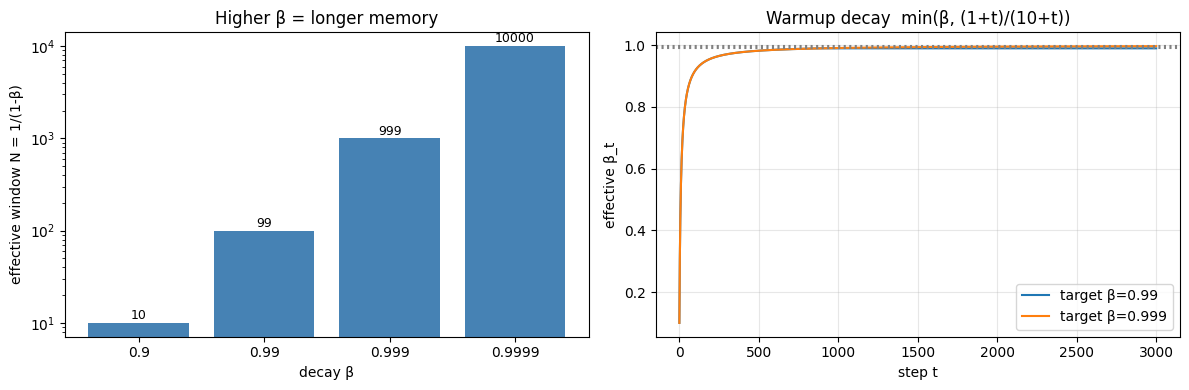

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# effective window vs decay
betas = np.array([0.9, 0.99, 0.999, 0.9999])
N = 1/(1-betas)
ax[0].bar([str(b) for b in betas], N, color='steelblue')
ax[0].set_yscale('log'); ax[0].set_ylabel('effective window N = 1/(1-β)')
ax[0].set_xlabel('decay β'); ax[0].set_title('Higher β = longer memory')
for i,(b,n) in enumerate(zip(betas,N)): ax[0].text(i, n*1.1, f'{int(n)}', ha='center', fontsize=9)

# warmup schedule
t = np.arange(0, 3000)
for target in [0.99, 0.999]:
    beta_t = np.minimum(target, (1+t)/(10+t))
    ax[1].plot(t, beta_t, label=f'target β={target}')
ax[1].axhline(0.99, ls=':', color='gray'); ax[1].axhline(0.999, ls=':', color='gray')
ax[1].set_xlabel('step t'); ax[1].set_ylabel('effective β_t')
ax[1].set_title('Warmup decay  min(β, (1+t)/(10+t))'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. EMA on a Real Model (digits MLP)

We train a small MLP on `sklearn` digits with a **deliberately high, constant LR** so the raw
weights oscillate around the basin. We track validation accuracy of the **raw** weights vs the
**EMA** shadow after every epoch.


In [5]:
d = load_digits()
X = (d.data.astype(np.float32) / 16.0)
y = d.target.astype(np.int64)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
Xtr_t, ytr_t = torch.tensor(Xtr), torch.tensor(ytr)
Xte_t, yte_t = torch.tensor(Xte), torch.tensor(yte)
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xtr_t, ytr_t), batch_size=32, shuffle=True)

class MLP(nn.Module):
    def __init__(self, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, h), nn.BatchNorm1d(h), nn.ReLU(),
            nn.Linear(h, h), nn.BatchNorm1d(h), nn.ReLU(),
            nn.Linear(h, 10))
    def forward(self, x): return self.net(x)

@torch.no_grad()
def acc(model):
    model.eval()
    return (model(Xte_t).argmax(1) == yte_t).float().mean().item()

torch.manual_seed(1); np.random.seed(1)
model = MLP()
ema = ModelEMA(model, decay=0.99, warmup=True)      # N~100 steps; warmup
opt = torch.optim.SGD(model.parameters(), lr=0.4, momentum=0.9)   # high LR -> oscillation

ema_model = MLP()                                   # a throwaway net to load the shadow into
hist_raw, hist_ema = [], []
EPOCHS = 40
for ep in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        F.cross_entropy(model(xb), yb).backward()
        opt.step()
        ema.update(model)                            # <-- after the optimizer step
    hist_raw.append(acc(model))
    ema.copy_to(ema_model); hist_ema.append(acc(ema_model))

print(f"final  raw={hist_raw[-1]:.4f}   ema={hist_ema[-1]:.4f}")
print(f"best   raw={max(hist_raw):.4f}   ema={max(hist_ema):.4f}")
print(f"std over last 10 epochs   raw={np.std(hist_raw[-10:]):.4f}   ema={np.std(hist_ema[-10:]):.4f}")


final  raw=0.9519   ema=0.9593
best   raw=0.9815   ema=0.9889
std over last 10 epochs   raw=0.0212   ema=0.0055


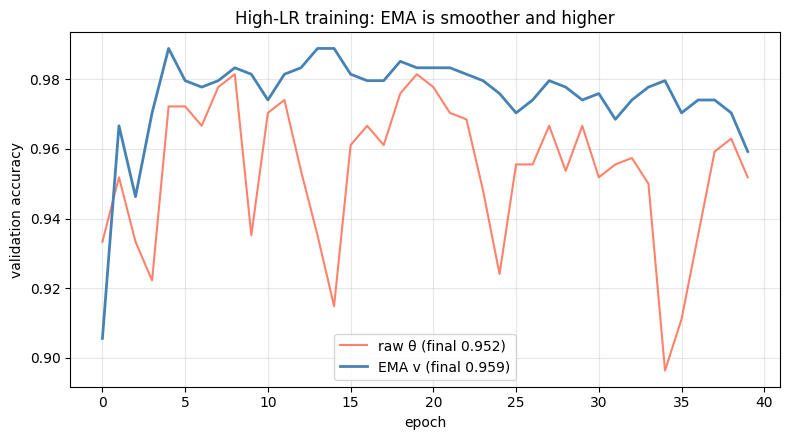

In [6]:
plt.figure(figsize=(8,4.5))
plt.plot(hist_raw, color='tomato', alpha=0.8, label=f'raw θ (final {hist_raw[-1]:.3f})')
plt.plot(hist_ema, color='steelblue', lw=2, label=f'EMA v (final {hist_ema[-1]:.3f})')
plt.xlabel('epoch'); plt.ylabel('validation accuracy')
plt.title('High-LR training: EMA is smoother and higher')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 4. The BatchNorm-Buffer Pitfall

A very common bug: EMA only the `parameters()` and forget the **buffers**. BatchNorm's
`running_mean` / `running_var` are buffers — if the shadow keeps their *initial* values
(`mean=0, var=1`) it evaluates terribly. We reproduce the bug and the fix.


In [7]:
# Take the trained model and build two shadows from the SAME training, conceptually:
#  (good) EMA the full state_dict (params + BN buffers)  -> ema_model above
#  (buggy) EMA only parameters; BN buffers left at init  -> reproduce here

buggy = MLP()
# load EMA'd parameters but KEEP buggy's freshly-initialized BN buffers (mean=0, var=1)
good_sd = ema.shadow
buggy_sd = buggy.state_dict()
for k in buggy_sd:
    if k.endswith('weight') or k.endswith('bias'):   # parameters only
        if good_sd[k].shape == buggy_sd[k].shape:
            buggy_sd[k] = good_sd[k].clone()
    # BN running_mean/running_var/num_batches_tracked: left at init (the bug)
buggy.load_state_dict(buggy_sd)

ema.copy_to(ema_model)
print(f"EMA (full state_dict, params+buffers) : {acc(ema_model):.4f}   <- correct")
print(f"EMA params only, BN buffers at init   : {acc(buggy):.4f}   <- the bug")
print("\nLesson: EMA/copy the buffers too. The minimal ModelEMA above iterates the")
print("full state_dict, so BatchNorm running stats are averaged along with the weights.")


EMA (full state_dict, params+buffers) : 0.9593   <- correct
EMA params only, BN buffers at init   : 0.7833   <- the bug

Lesson: EMA/copy the buffers too. The minimal ModelEMA above iterates the
full state_dict, so BatchNorm running stats are averaged along with the weights.


## 5. Takeaways

- EMA averages the **weight trajectory**, cancelling the zero-mean noise of finite-LR SGD →
  a tighter, better-generalizing point (§1). The benefit grows with LR/noise and run length.
- Match the decay to the run: **`N ≈ 1/(1-β)`**, and use **warmup** so the shadow isn't stuck
  near init early on (§2).
- On a real model with a high LR, the EMA validation curve is **smoother and higher** than the
  raw weights (§3) — for essentially free (one extra weight copy, no extra forward passes).
- **EMA the buffers, not just the parameters** — the BatchNorm-stats bug is the #1 footgun (§4).

EMA is the same mechanism behind diffusion EMA weights, MoCo/BYOL momentum encoders, Mean-Teacher,
and RL target networks — see [weight_ema.md](weight_ema.md) §6.
